### Step 2 - Lineage Composition Over Time
In this tutorial, you'll plot which SARS-CoV-2 lineages were circulating in the clinical samples collected in San Diego, and see why so many rare lineages need to be grouped together before the trend is actually readable. As before, run each cell in order until you've completed the notebook.

#### Imports
As in Step 1, we need pandas to work with the metadata table, seaborn for plotting, and matplotlib for finer control over the figure. We also need `json` and `os` to load the curated lineage groupings and read the per-sample Freyja files.

In [1]:
import json
import os

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### Load the clinical metadata
Load the clinical sample metadata, which contains sample ids, collection dates, and the lineage assigned to each sample.

In [2]:
clinical_metadata = pd.read_csv("../data/clinical_metadata.csv")

#### Plot all circulating lineages over time
To see how lineage composition shifted over time, bin samples by week and compute what percent of that week's samples each lineage made up. Stacking these percentages produces a filled area plot that always sums to 100%.

In [3]:
clinical_metadata["year_week"] = pd.to_datetime(clinical_metadata["collection_date"]).dt.strftime("%G-W%V")

weekly_counts_all = clinical_metadata.groupby(["year_week", "lineage"]).size().unstack(fill_value=0)
weekly_pct_all = weekly_counts_all.div(weekly_counts_all.sum(axis=1), axis=0) * 100

# order columns by overall prevalence, most common at the bottom of the stack
lineage_order_all = weekly_pct_all.sum().sort_values(ascending=False).index
weekly_pct_all = weekly_pct_all[lineage_order_all]

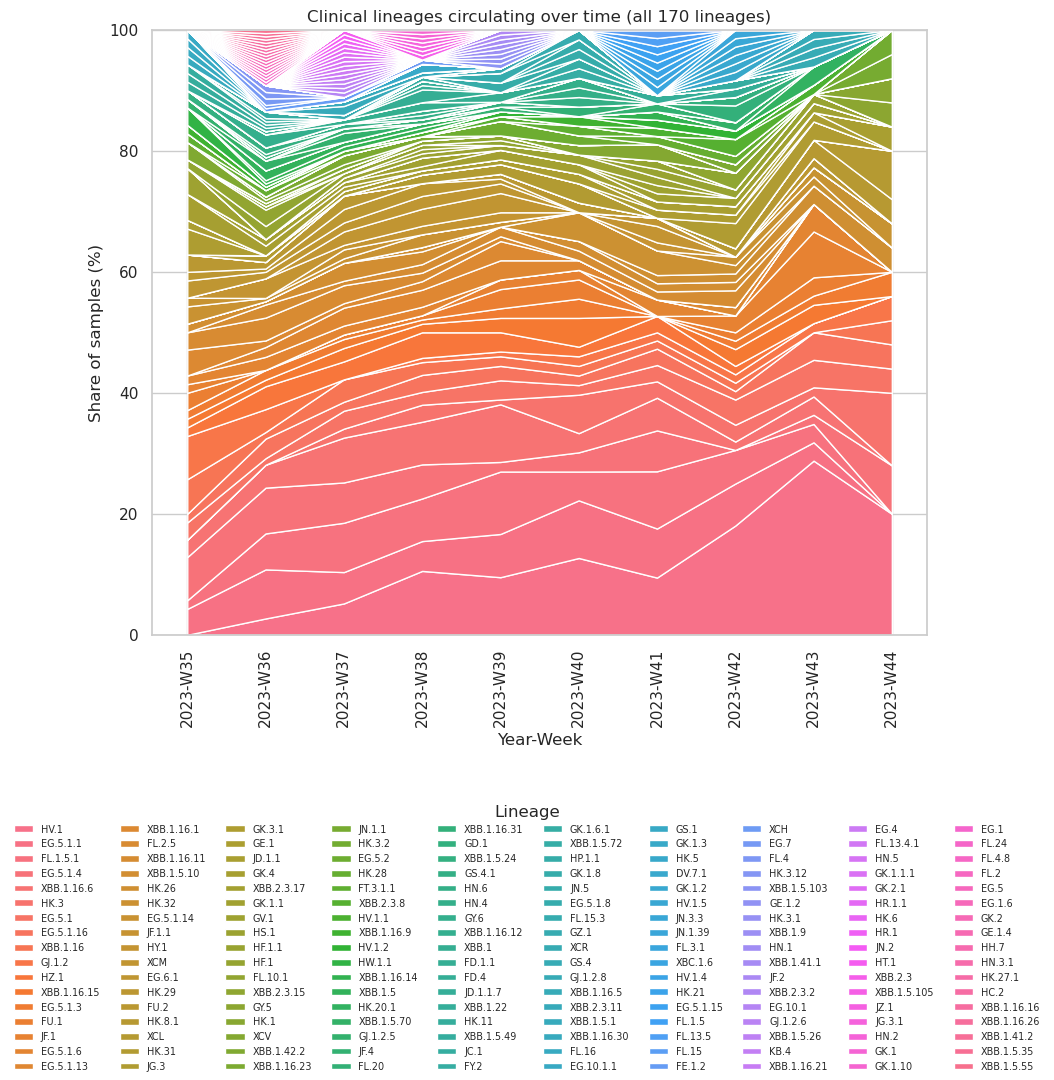

In [4]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 11))
colors_all = sns.color_palette("husl", n_colors=weekly_pct_all.shape[1])
ax.stackplot(
    weekly_pct_all.index,
    weekly_pct_all.T.values,
    labels=weekly_pct_all.columns,
    colors=colors_all,
    baseline="zero",
)
ax.set_ylim(0, 100)
ax.set_xlabel("Year-Week")
ax.set_ylabel("Share of samples (%)")
ax.set_title(f"Clinical lineages circulating over time (all {weekly_pct_all.shape[1]} lineages)")
plt.setp(ax.get_xticklabels(), rotation=90)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=10, fontsize="xx-small", frameon=False, title="Lineage")
fig.subplots_adjust(top=0.95, bottom=0.4)
plt.show()

#### Group into curated lineage clades
Instead of a data-driven prevalence threshold, we can map each clinical lineage onto curated lineage groupings — the same `../data/curated_lineages.json` file Freyja uses internally to compute its `summarized` column. Each entry lists a named clade (e.g. `EG.5* [Omicron (EG.5.X)]`) and every Pango lineage that belongs to it (`pango_descendants`). Anything with no curated entry falls into `Other` (mostly rare recombinants not yet covered by the curation). Plot 4 applies this exact same `lineage_to_group` mapping to the wastewater data, so any difference between the two plots reflects a real clinical-vs-wastewater signal rather than an artifact of using different grouping rules.

In [14]:
with open("../data/curated_lineages.json") as f:
    curated_lineages = json.load(f)

# broadest clades first, so more specific descendant lists overwrite them below
curated_lineages = sorted(curated_lineages, key=lambda rec: len(rec.get("pango_descendants", [])), reverse=True)

lineage_to_group = {}
for record in curated_lineages:
    who_name = record.get("who_name")
    if who_name is None:
        continue
    for descendant in record.get("pango_descendants", []):
        lineage_to_group[descendant] = who_name


def assign_group(lineage):
    if lineage in lineage_to_group:
        return lineage_to_group[lineage]
    elif lineage == "A" or lineage.startswith("A."):
        return "A"
    else:
        return "Other"


clinical_metadata["lineage_group"] = clinical_metadata["lineage"].map(assign_group)

weekly_counts_top = clinical_metadata.groupby(["year_week", "lineage_group"]).size().unstack(fill_value=0)
weekly_pct_top = weekly_counts_top.div(weekly_counts_top.sum(axis=1), axis=0) * 100

# order columns by overall prevalence, "Other" always last
lineage_order_top = [g for g in weekly_pct_top.sum().sort_values(ascending=False).index if g != "Other"]
if "Other" in weekly_pct_top.columns:
    lineage_order_top.append("Other")
weekly_pct_top = weekly_pct_top[lineage_order_top]

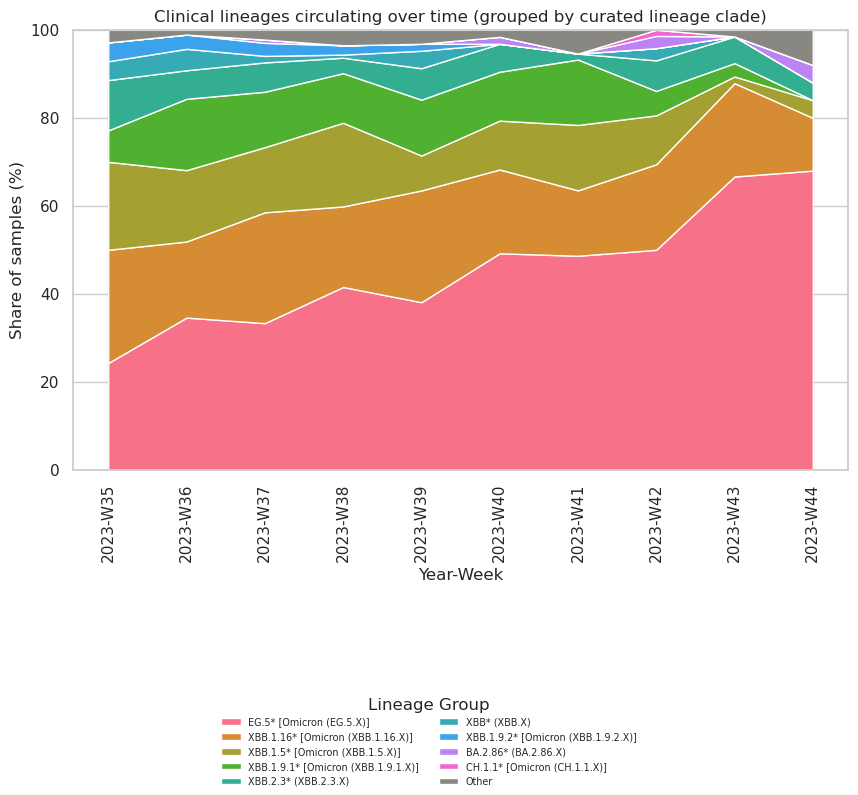

In [15]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 8))
colors_top = sns.color_palette("husl", n_colors=len(lineage_order_top) - 1) + ["#898781"]  # neutral gray for Other
ax.stackplot(
    weekly_pct_top.index,
    weekly_pct_top.T.values,
    labels=lineage_order_top,
    colors=colors_top,
    baseline="zero",
)
ax.set_ylim(0, 100)
ax.set_xlabel("Year-Week")
ax.set_ylabel("Share of samples (%)")
ax.set_title("Clinical lineages circulating over time (grouped by curated lineage clade)")
plt.setp(ax.get_xticklabels(), rotation=90)

handles, labels = ax.get_legend_handles_labels()
ncol = 2
rows = -(-len(labels) // ncol)
fig.legend(handles, labels, loc="lower center", ncol=ncol, fontsize="xx-small", frameon=False, title="Lineage Group")
fig.subplots_adjust(top=0.95, bottom=min(0.5, 0.15 + 0.05 * rows))
plt.show()

### Wastewater Samples
Now let's repeat this analysis for the community wastewater samples, so we can compare the wastewater signal against what we just saw in the clinical samples.

#### Load the wastewater metadata
Just like the clinical metadata, this file has a sample id and a collection date for each wastewater sample. 

In [16]:
wastewater_metadata = pd.read_csv("../data/wastewater_metadata.csv")
wastewater_metadata["year_week"] = pd.to_datetime(wastewater_metadata["collection_date"]).dt.strftime("%G-W%V")

#### Load the Freyja lineage abundances
Wastewater samples are a mixture of many people's virus, so there's no single "lineage" per sample the way there is for a clinical isolate. Instead, each sample has its own file in `../data/freyja_demix/` produced by [Freyja](https://github.com/andersen-lab/Freyja), which deconvolves the mixture into a `lineages` row and a matching `abundances` row — the estimated relative abundance of every lineage detected in that sample. We read all 70 files and stack them into one long table of `(sample_id, lineage, abundance)`.

In [17]:
demix_dir = "../data/freyja_demix"
records = []
for filename in os.listdir(demix_dir):
    if not filename.endswith(".demix.tsv"):
        continue
    sample_id = filename.replace(".demix.tsv", "")
    demix = pd.read_csv(os.path.join(demix_dir, filename), sep="\t", header=None, index_col=0)
    lineages = demix.loc["lineages"].dropna().iloc[0].split()
    abundances = [float(x) for x in demix.loc["abundances"].dropna().iloc[0].split()]
    for lineage, abundance in zip(lineages, abundances):
        records.append((sample_id, lineage, abundance))

wastewater_long = pd.DataFrame(records, columns=["sample_id", "lineage", "abundance"])

#### Simplify to lineages that ever exceed 1%
Unlike the clinical plot above, here we compute each lineage's average weekly share, keep any lineage that reaches at least 1% in at least one week and fold everything else into `Other`. Plot 4 below repeats this wastewater data with the curated-clade grouping instead, for a direct comparison against Plot 2.

In [18]:
# normalize each sample's abundances to 100%, then average samples within the same week
sample_lineage_abundance = wastewater_long.groupby(["sample_id", "lineage"])["abundance"].sum().unstack(fill_value=0)
sample_lineage_pct = sample_lineage_abundance.div(sample_lineage_abundance.sum(axis=1), axis=0) * 100

sample_year_week = wastewater_metadata.set_index("sample_id")["year_week"]
sample_lineage_pct["year_week"] = sample_lineage_pct.index.map(sample_year_week)
weekly_pct_all_ww = sample_lineage_pct.groupby("year_week").mean()

In [19]:
lineage_threshold = 1  # minimum % share needed in at least one week to get its own bucket (matches Freyja's `freyja plot --thresh` default of 0.01)

kept_lineages_ww = weekly_pct_all_ww.columns[(weekly_pct_all_ww >= lineage_threshold).any(axis=0)]

weekly_pct_ww = weekly_pct_all_ww[kept_lineages_ww].copy()
weekly_pct_ww["Other"] = weekly_pct_all_ww.drop(columns=kept_lineages_ww).sum(axis=1)

# order columns by overall prevalence, "Other" always last
lineage_order_ww = (
    weekly_pct_ww.drop(columns="Other").sum().sort_values(ascending=False).index.tolist() + ["Other"]
)
weekly_pct_ww = weekly_pct_ww[lineage_order_ww]

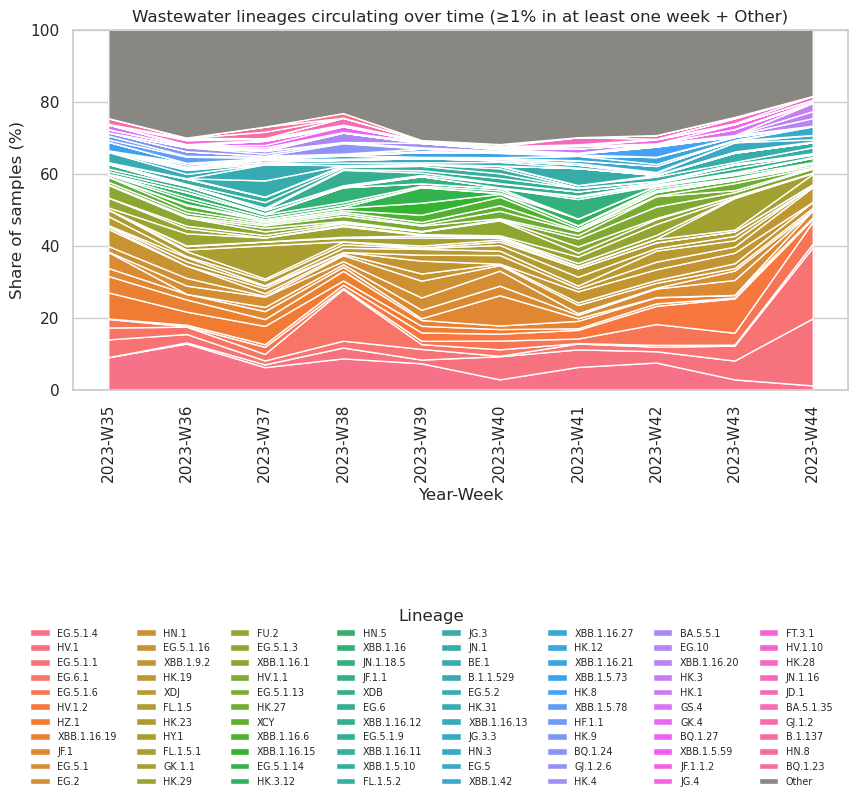

In [20]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 8))
colors_ww = sns.color_palette("husl", n_colors=len(lineage_order_ww) - 1) + ["#898781"]  # neutral gray for Other
ax.stackplot(
    weekly_pct_ww.index,
    weekly_pct_ww.T.values,
    labels=lineage_order_ww,
    colors=colors_ww,
    baseline="zero",
)
ax.set_ylim(0, 100)
ax.set_xlabel("Year-Week")
ax.set_ylabel("Share of samples (%)")
ax.set_title(f"Wastewater lineages circulating over time (≥{lineage_threshold}% in at least one week + Other)")
plt.setp(ax.get_xticklabels(), rotation=90)

handles, labels = ax.get_legend_handles_labels()
ncol = 8
rows = -(-len(labels) // ncol)
fig.legend(handles, labels, loc="lower center", ncol=ncol, fontsize="xx-small", frameon=False, title="Lineage")
fig.subplots_adjust(top=0.95, bottom=min(0.5, 0.12 + 0.045 * rows))
plt.show()

#### Group into curated lineage clades
Same idea as Plot 2, applied here to the wastewater abundances instead of clinical sample counts: we reuse the exact same `lineage_to_group` mapping built from `../data/curated_lineages.json`, re-summing each sample's per-lineage abundances into their curated clade, renormalizing to 100%, then averaging across samples collected in the same week. Because Plot 2 and Plot 4 share the identical lineage-to-clade mapping, this is the fairest side-by-side comparison of the clinical and wastewater signal in this notebook.

In [21]:
wastewater_long["lineage_group"] = wastewater_long["lineage"].map(assign_group)

sample_group_abundance = wastewater_long.groupby(["sample_id", "lineage_group"])["abundance"].sum().unstack(fill_value=0)
sample_group_pct = sample_group_abundance.div(sample_group_abundance.sum(axis=1), axis=0) * 100

sample_group_pct["year_week"] = sample_group_pct.index.map(sample_year_week)
weekly_pct_group_ww = sample_group_pct.groupby("year_week").mean()

# order columns by overall prevalence, "Other" always last
lineage_order_group_ww = [g for g in weekly_pct_group_ww.sum().sort_values(ascending=False).index if g != "Other"]
if "Other" in weekly_pct_group_ww.columns:
    lineage_order_group_ww.append("Other")
weekly_pct_group_ww = weekly_pct_group_ww[lineage_order_group_ww]

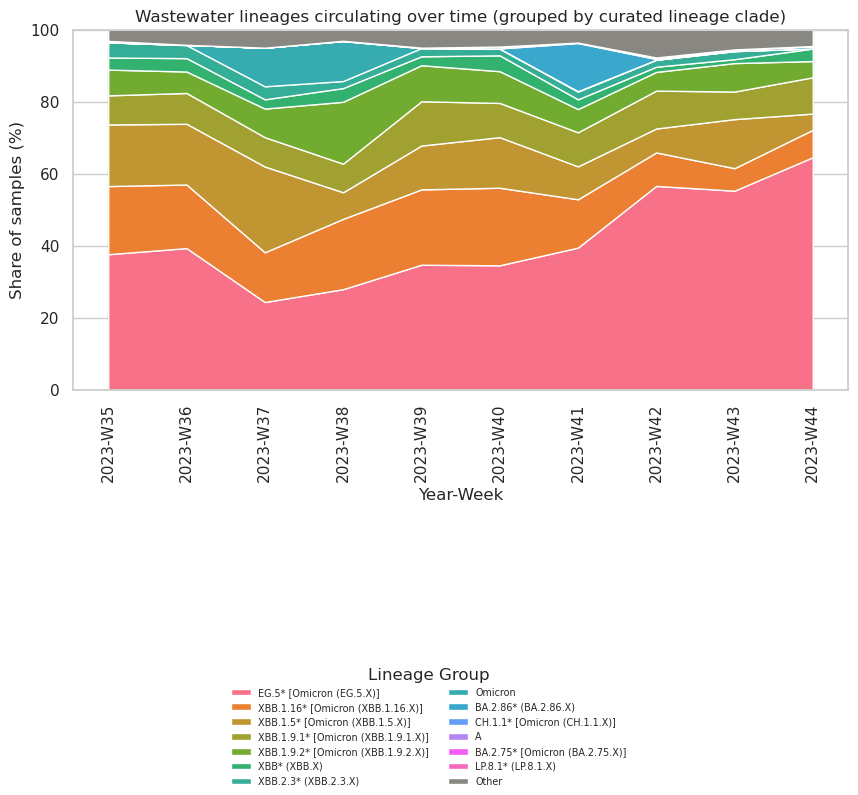

In [22]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 8))
colors_group_ww = sns.color_palette("husl", n_colors=len(lineage_order_group_ww) - 1) + ["#898781"]  # neutral gray for Other
ax.stackplot(
    weekly_pct_group_ww.index,
    weekly_pct_group_ww.T.values,
    labels=lineage_order_group_ww,
    colors=colors_group_ww,
    baseline="zero",
)
ax.set_ylim(0, 100)
ax.set_xlabel("Year-Week")
ax.set_ylabel("Share of samples (%)")
ax.set_title("Wastewater lineages circulating over time (grouped by curated lineage clade)")
plt.setp(ax.get_xticklabels(), rotation=90)

handles, labels = ax.get_legend_handles_labels()
ncol = 2
rows = -(-len(labels) // ncol)
fig.legend(handles, labels, loc="lower center", ncol=ncol, fontsize="xx-small", frameon=False, title="Lineage Group")
fig.subplots_adjust(top=0.95, bottom=min(0.5, 0.15 + 0.05 * rows))
plt.show()

#### Wrap Up
Notice the number of lineages shown in the wastewater plots vs. the clinical plots. Which has more and why? Does the lineage prevalence over time trend agree or disagree between the two sampling types?